## PyTorch Fashion MNIST DataSet

- 기본 MLP(다층 퍼셉트론)으로 분류
- 로지스틱 회귀

### 1. 데이터 준비

In [30]:
# 라이브러리 로드
import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # sm_120 의미 12.0 버전

2.12.0+cu130
13.0
NVIDIA GeForce RTX 5060
(12, 0)


### 2. 데이터전처리

In [3]:
transform = transforms.Compose([
    # 1. 이미지를 Tensor 형태로 변환 (0.0 ~ 1.0)
    transforms.ToTensor(),
    
    # 2. 데이터 정규화 (평균, 표준편차)
    # Fashion-MNIST의 대략적인 평균인 0.2860과 표준편차 0.3530을 적용하거나,
    # 일반적으로 많이 쓰는 0.5, 0.5를 지정해 [-1, 1] 범위로 맞춥니다.
    transforms.Normalize((0.5,), (0.5,))
])

### 3. FashionMNIST 데이터셋 다운로드(학습데이터/테스트데이터)

In [4]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data', 
    # 학습용 데이터셋 사용여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # 트랜스폼 적용
    transform=transform
)

In [5]:
# 학습용 데이터 6만개
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 4. 데이터셋을 학습데이터로더로 변경

In [21]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터 개수 지정
    batch_size=64,
    # 데이터를 매 epoch 마다 데이터 섞기
    shuffle=True,

    num_workers=4,

    pin_memory=True
)

### 5. 테스트 데이터셋 다운로드

In [7]:
# 테스트 데이터
test_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data', 
    # 테스트 데이터
    train=False,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # 트랜스폼 적용
    transform=transforms
)

In [8]:
# Test데이터 10000개
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: <module 'torchvision.transforms' from 'c:\\SourceBank\\iot-python-2026\\iot-venv\\Lib\\site-packages\\torchvision\\transforms\\__init__.py'>

### 6. 데이터셋을 테스트 데이터로더로 변경

In [9]:
# 테스트 데이터로더 생성
test_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    test_dataset,
    # 한번에 가져올 데이터 개수 지정
    batch_size=64,
    # 테스트 데이터는 섞을 필요 없음
    shuffle=False
)

### 7. PyTorch GPU 사용가능 여부확인
- Compute Unified Device Architecture : NVIDIA가 제공하는 GPU 병렬컴퓨팅 플랫폼

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
f'사용 장치 : {device}'

'사용 장치 : cuda'

### 8. FashionMNIST 클래스(분류) 이름 지정

In [11]:
classes = [
    'T-shirt/top', # 티셔츠
    'Trouser', # 바지
    'Pullover', # 풀오버
    'Dress', # 드레스
    'Coat', # 코드
    'Sandal', # 샌들
    'Shirt', # 셔츠
    'Sneaker', # 스니커즈
    'Bag', # 가방
    'Ankle boot', # 발목부츠
]

### 9. 이미지 확인

Tensor shape : torch.Size([1, 28, 28])
Label : 9
Class name : Ankle boot


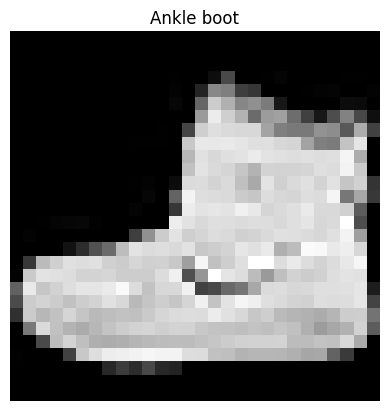

In [12]:
import matplotlib.pyplot as plt

# 데이터셋에서 첫번째 데이터
image, label = train_dataset[0]

print(f'Tensor shape : {image.shape}')
print(f'Label : {label}')
print(f'Class name : {classes[label]}')

# 이미지 출력
# [1, 28, 28] -> [28, 28]

plt.imshow(image.squeeze(), cmap='gray')
plt.title(classes[label])
plt.axis('off')
plt.show()

### 10
. 일반 로지스틱회귀
- CNN 사용안함, 이미지를 1차원 벡터로 펼쳐서 분류

In [13]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력크기 28 x 28 = 784
        # 출력크기 클래스 개수 = 10
        self.linear = nn.Linear(28 * 28, 10) 

    def forward(self, x):
        # 이미지 펼치기(벡터로 변경)
        # [64, 1, 28, 28] -> [64, 784]
        x = x.view(x.size(0), -1)
        
        # 선형 레이어 통과
        x = self.linear(x)
        return x

11. 모델 객체 생성

In [14]:
model = LogisticRegression()
# 모델 객체 생성 시 모델 객체도 GPU로 이동
model = model.to(device)

In [15]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

2.12.0+cu130
13.0
NVIDIA GeForce RTX 5060
(12, 0)


### 12. 손실함수 정의

In [16]:
# 다중클래스 분류에 사용하는 손실함수
loss_fn = nn.CrossEntropyLoss()


### 13. 최적화 알고리즘 정의

- 확률적 경사하강법 사용

In [17]:
optimizer = optim.SGD(
    model.parameters(),
    lr = 0.01
)
# optimizer = optim.Adam

### 14. 모델 학습

In [27]:
# 먼저 사용할 디바이스를 정의해둡니다 (보통 코드 최상단에 위치)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 만약 모델을 올릴 때 device 지정을 다르게 하셨다면 그 변수명을 쓰시면 됩니다.
# 예: model.to(device)

num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        
        # 💡 [수정] 데이터와 레이블을 GPU(device)로 이동시킵니다.
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산 
        outputs = model(images)

        # 손실 계산
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1} / {num_epochs}] Loss : {avg_loss:.4f}')

[Epoch 1 / 10] Loss : 0.3954
[Epoch 2 / 10] Loss : 0.3944
[Epoch 3 / 10] Loss : 0.3938
[Epoch 4 / 10] Loss : 0.3933
[Epoch 5 / 10] Loss : 0.3924
[Epoch 6 / 10] Loss : 0.3919
[Epoch 7 / 10] Loss : 0.3906
[Epoch 8 / 10] Loss : 0.3904
[Epoch 9 / 10] Loss : 0.3899
[Epoch 10 / 10] Loss : 0.3891


### 모델 평가(테스트)

In [28]:
model.eval()

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

In [29]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 예측
        outputs = model(images)

        # 가장 높은 확률을 선택
        _, pred = torch.max(outputs, 1)

        total+= labels.size(0)
        correct += (pred == labels).sum().item()

accuracy = 100 * (correct/total)

print(f'테스트 정확도 :{accuracy:.2f}%')

TypeError: 'module' object is not callable